<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/EarlyFusionCNN_Standardized_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Imports and Reproducibility

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using device: cuda
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 (DF Index: 521) | True: 1 | Pred: 0 | Confidence: 0.8899 | Uncertainty (Std): 0.0000
Sample 001 (DF Index: 737) | True: 0 | Pred: 0 | Confidence: 0.6509 | Uncertainty (Std): 0.0000
Sample 002 (DF Index: 740) | True: 0 | Pred: 1 | Confidence: 0.7871 | Uncertainty (Std): 0.0000
Sample 003 (DF Index: 660) | True: 0 | Pred: 0 | Confidence: 0.7422 | Uncertainty (Std): 0.0000
Sample 004 (DF Index: 411) | True: 0 | Pred: 0 | Confidence: 0.5276 | Uncertainty (Std): 0.0000
Sample 005 (DF Index: 678) | True: 0 | Pred: 0 | Confidence: 0.5358 | Uncertainty (Std): 0.0000
Sample 006 (DF Index: 626) | True: 0 | Pred: 0 | Confidence: 0.8740 | Uncertainty (Std): 0.0000
Sample 007 (DF Index: 513) | True: 0 | Pred: 1 | Confidence: 0.8528 | Uncertainty (Std): 0.0000
Sample 008 (DF Index: 859) | True: 0 | Pred: 0 | Confidence: 0.5902 | Uncertainty (Std): 0.0000
Sample 009 (D

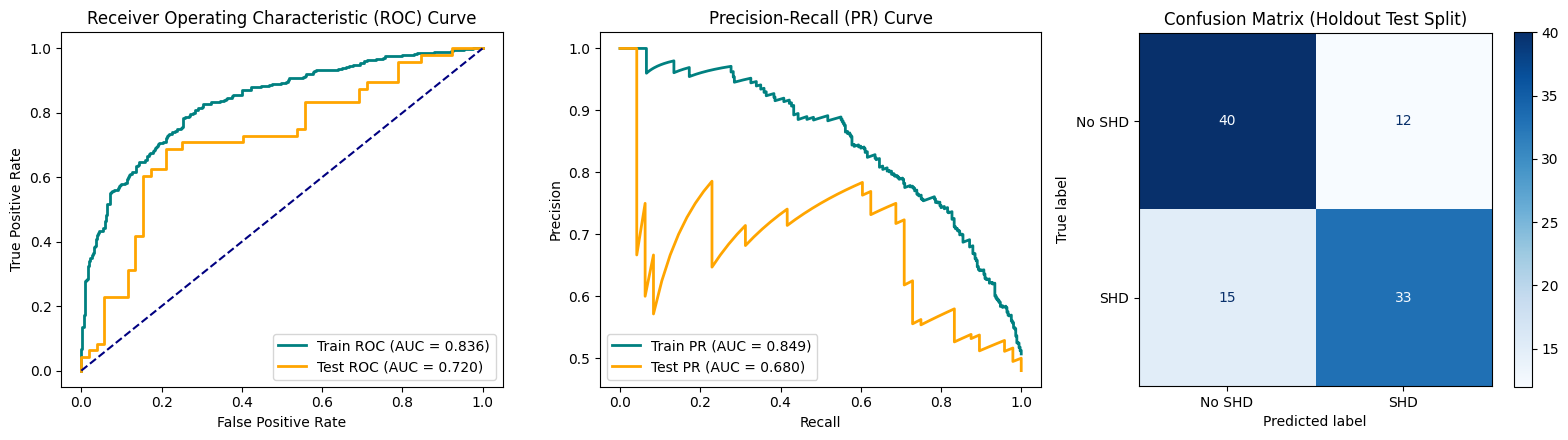

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)

# ──────────────────────────────────────────────────────────────────────
# 1. GLOBAL CONFIGURATION & REPRODUCIBILITY
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected"
]
ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS

ECG_SAMPLING_RATE_HZ = 500
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# ──────────────────────────────────────────────────────────────────────
# 2. SIGNAL PROCESSING & PREPROCESSING PIPELINES
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

def preprocess_demographics_pipeline(
    df: pd.DataFrame,
    scaler: StandardScaler = None,
    imputer: KNNImputer = None,
    knn_k: int = 5,
    fit: bool = True,
    known_feature_names: list = None
):
    df_working = df[ALL_DEMO_COLS].copy()

    cat_codes = df_working[CATEGORICAL_COLS].apply(
        lambda col: col.astype("category").cat.codes.replace(-1, np.nan)
    )
    cont_part = df_working[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    if imputer is None:
        imputer = KNNImputer(n_neighbors=knn_k)

    if fit:
        imputed = imputer.fit_transform(imputer_input)
    else:
        imputed = imputer.transform(imputer_input)

    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df_working.index)

    for col in CATEGORICAL_COLS:
        original_cats = df_working[col].astype("category").cat.categories
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = original_cats[codes_rounded].values

    ohe_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)

    if fit:
        current_feature_names = list(ohe_df.columns)
    else:
        if known_feature_names is None:
            raise ValueError("known_feature_names must be provided when fit=False")
        ohe_df = ohe_df.reindex(columns=known_feature_names, fill_value=0)
        current_feature_names = known_feature_names

    if scaler is None:
        scaler = StandardScaler()

    cont_indices = [current_feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)

    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, imputer, current_feature_names

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATASET INFRASTRUCTURE
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts, X_demo, y):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch across tensor targets."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. NEURAL NETWORK ARCHITECTURE (deterministic)
# ──────────────────────────────────────────────────────────────────────
class DemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)

class HeartDiseaseNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demo_dim=20):
        super().__init__()

        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),
        )

        self.demog_features = DemographicMLP(input_dim=demo_dim, output_dim=16)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + 16, num_classes)
        )

    def forward(self, ts_input, demog_input):
        ts_emb = self.ts_features(ts_input)
        ts_emb = torch.flatten(ts_emb, start_dim=1)

        demog_emb = self.demog_features(demog_input)
        fused_features = torch.cat((ts_emb, demog_emb), dim=1)

        logits = self.classifier(fused_features)
        return logits

# ──────────────────────────────────────────────────────────────────────
# 5. TRAINING ROUTINE
# ──────────────────────────────────────────────────────────────────────
def train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    for epoch in range(epochs):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)

            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, X_demo_v, y_v in val_loader:
                X_ts_v, X_demo_v, y_v = X_ts_v.to(device), X_demo_v.to(device), y_v.to(device)
                logits_v = model(X_ts_v, X_demo_v)
                val_loss += criterion(logits_v, y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        scheduler.step(val_loss / val_total)

# ──────────────────────────────────────────────────────────────────────
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
#    (matches the Bayesian-model script's format exactly)
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader):
    """
    Deterministic equivalent of the Bayesian version's function:
    single forward pass instead of averaging over stochastic samples.
    """
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs = torch.softmax(logits, dim=-1)

            all_nll += criterion(torch.log(probs + 1e-8), y_b.to(device)).item()

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader):
    """
    Exact port of the Bayesian script's version — same printed table
    and same 3-panel figure (ROC, PR, test confusion matrix).
    """
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 7. EXECUTION PIPELINE EXECUTION
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    ecg_path = 'ECG_waveforms_1K.npy'
    echo_path = 'EchoNext_EchoData_5K.csv'

    X_raw = np.load(ecg_path)[:1000]
    echo_df = pd.read_csv(echo_path).iloc[:1000].reset_index(drop=True)
    y_raw = echo_df['shd_moderate_or_greater_flag'].to_numpy()

    # ── STEP B: WAVEFORM PRE-FILTERING ──────────────────────────────
    X_filtered = np.array([bandpass_filter_ecg(x, fs=250) for x in X_raw])
    X_ts = np.swapaxes(X_filtered, 1, 2)
    demo_df = echo_df[ALL_DEMO_COLS].copy()

    # ── STEP C: DATASET PARTITIONING ──
    N = len(y_raw)
    indices = np.arange(N)
    np.random.seed(RANDOM_SEED)
    np.random.shuffle(indices)

    test_split_idx = int(0.10 * N)
    test_indices = indices[:test_split_idx]
    train_val_indices = indices[test_split_idx:]

    val_split_idx = int(0.20 * len(train_val_indices))
    val_indices = train_val_indices[:val_split_idx]
    train_indices = train_val_indices[val_split_idx:]

    # ── STEP D: TRANSFORM DEMOGRAPHICS ──
    train_val_df_raw = demo_df.iloc[train_val_indices]
    _, fitted_scaler, fitted_imputer, fitted_feature_names = preprocess_demographics_pipeline(
        train_val_df_raw, scaler=None, imputer=None, fit=True
    )

    demo_train, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[train_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )
    demo_val, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[val_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )
    demo_test, _, _, _ = preprocess_demographics_pipeline(
        demo_df.iloc[test_indices], scaler=fitted_scaler, imputer=fitted_imputer,
        fit=False, known_feature_names=fitted_feature_names
    )

    train_loader = DataLoader(FusedDataset(X_ts[train_indices], demo_train, y_raw[train_indices]), batch_size=32, shuffle=False)
    val_loader   = DataLoader(FusedDataset(X_ts[val_indices],   demo_val,   y_raw[val_indices]),   batch_size=128, shuffle=False)
    test_loader  = DataLoader(FusedDataset(X_ts[test_indices],  demo_test,  y_raw[test_indices]),  batch_size=128, shuffle=False)

    # ── STEP E: INITIALIZE & TRAIN THE MODEL ──────────────────────────
    model = HeartDiseaseNet(
        sequence_length=X_ts.shape[2], in_channels=X_ts.shape[1],
        demo_dim=demo_train.shape[1], num_classes=2
    )

    print("Training model...")
    train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4)

    torch.manual_seed(RANDOM_SEED)

    # ── STEP F: PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ─────────────
    print("\n===== Individual Test Sample Inference Profiles ====")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in test_loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(probs[idx])
                confidence = probs[idx][pred_val]
                uncertainty = 0.0  # deterministic model: no posterior spread
                global_df_idx = test_indices[sample_counter]

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                      f"True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")
                sample_counter += 1

    # ── STEP G: SYSTEM METRICS ANALYSIS VISUALIZATIONS ────────────────
    generate_and_display_comparative_metrics(model, train_loader, test_loader)